In [1]:
import pandas as pd
# import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import sys
import os
from tqdm import tqdm


# feature_path = os.path.abspath(r"C:\Users\alexg\OneDrive\Documents\NBA-Prop-Predictor")
feature_path = os.path.abspath('/Users/alexg/Documents/Documents/Prize-Picks-Prop-Predictor')
if feature_path not in sys.path:
    sys.path.append(feature_path)

from FEATURE_ENGINEERING.features import *
from MODELS.pipeline import *

/Users/alexg/Documents/Documents/Prize-Picks-Prop-Predictor/myenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
pd.set_option('display.max_columns', None)
epsilon = 1e-8

s19 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_19.csv')
# player_avg_minutes = s19.groupby('PLAYER_NAME')['MIN'].mean().reset_index()
# player_avg_minutes.columns = ['PLAYER_NAME', 'AVG_MIN']
# players_over_20_min = player_avg_minutes[player_avg_minutes['AVG_MIN'] > 20]
# s19 = s19[s19['PLAYER_NAME'].isin(players_over_20_min['PLAYER_NAME'])]
s19['EXPECTED_USAGE_MIN'] = s19['USG_PCT_ROLLING_AVG_5'] * s19['MIN_ROLLING_AVG_5']

s20 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_20.csv')
# player_avg_minutes = s20.groupby('PLAYER_NAME')['MIN'].mean().reset_index()
# player_avg_minutes.columns = ['PLAYER_NAME', 'AVG_MIN']
# players_over_20_min = player_avg_minutes[player_avg_minutes['AVG_MIN'] > 20]
# s20 = s20[s20['PLAYER_NAME'].isin(players_over_20_min['PLAYER_NAME'])]
s20['EXPECTED_USAGE_MIN'] = s20['USG_PCT_ROLLING_AVG_5'] * s20['MIN_ROLLING_AVG_5']

s21 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_21.csv')
# player_avg_minutes = s21.groupby('PLAYER_NAME')['MIN'].mean().reset_index()
# player_avg_minutes.columns = ['PLAYER_NAME', 'AVG_MIN']
# players_over_20_min = player_avg_minutes[player_avg_minutes['AVG_MIN'] > 20]
# s21 = s21[s21['PLAYER_NAME'].isin(players_over_20_min['PLAYER_NAME'])]
s21['EXPECTED_USAGE_MIN'] = s21['USG_PCT_ROLLING_AVG_5'] * s21['MIN_ROLLING_AVG_5']

s22 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_22.csv')
# player_avg_minutes = s22.groupby('PLAYER_NAME')['MIN'].mean().reset_index()
# player_avg_minutes.columns = ['PLAYER_NAME', 'AVG_MIN']
# players_over_20_min = player_avg_minutes[player_avg_minutes['AVG_MIN'] > 20]
# s22 = s22[s22['PLAYER_NAME'].isin(players_over_20_min['PLAYER_NAME'])]
s22['EXPECTED_USAGE_MIN'] = s22['USG_PCT_ROLLING_AVG_5'] * s22['MIN_ROLLING_AVG_5']

s23 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_23.csv')
# player_avg_minutes = s23.groupby('PLAYER_NAME')['MIN'].mean().reset_index()
# player_avg_minutes.columns = ['PLAYER_NAME', 'AVG_MIN']
# players_over_20_min = player_avg_minutes[player_avg_minutes['AVG_MIN'] > 20]
# s23 = s23[s23['PLAYER_NAME'].isin(players_over_20_min['PLAYER_NAME'])]
s23['EXPECTED_USAGE_MIN'] = s23['USG_PCT_ROLLING_AVG_5'] * s23['MIN_ROLLING_AVG_5']

s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
# player_avg_minutes = s24.groupby('PLAYER_NAME')['MIN'].mean().reset_index()
# player_avg_minutes.columns = ['PLAYER_NAME', 'AVG_MIN']
# players_over_20_min = player_avg_minutes[player_avg_minutes['AVG_MIN'] > 20]
# s24 = s24[s24['PLAYER_NAME'].isin(players_over_20_min['PLAYER_NAME'])]
s24['EXPECTED_USAGE_MIN'] = s24['USG_PCT_ROLLING_AVG_5'] * s24['MIN_ROLLING_AVG_5']


s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
# player_avg_minutes = s25.groupby('PLAYER_NAME')['MIN'].mean().reset_index()
# player_avg_minutes.columns = ['PLAYER_NAME', 'AVG_MIN']
# players_over_20_min = player_avg_minutes[player_avg_minutes['AVG_MIN'] > 20]
# s25 = s25[s25['PLAYER_NAME'].isin(players_over_20_min['PLAYER_NAME'])]
s25['EXPECTED_USAGE_MIN'] = s25['USG_PCT_ROLLING_AVG_5'] * s25['MIN_ROLLING_AVG_5']

train_df = pd.concat([s19,s20,s21,s22,s23])
val_df = s24
test_df = s25

print(f"Training data shape: {train_df.shape}")
print(f"Training date range: {train_df['GAME_DATE'].min()} to {train_df['GAME_DATE'].max()}")
print(f"Validation data shape: {val_df.shape}")
print(f"Validation date range: {val_df['GAME_DATE'].min()} to {val_df['GAME_DATE'].max()}")
print(f"Test data shape: {test_df.shape}")
print(f"Test date range: {test_df['GAME_DATE'].min()} to {test_df['GAME_DATE'].max()}")
train_df.tail()

Training data shape: (123509, 673)
Training date range: 2018-10-16 to 2023-04-09
Validation data shape: (26401, 660)
Validation date range: 2023-10-24 to 2024-04-14
Test data shape: (26306, 660)
Test date range: 2024-10-22 to 2025-04-13


,Unnamed: 0,Unnamed: 0.2,PLAYER_NAME,PLAYER_ID,MATCHUP,TEAM_ABBREVIATION,TEAM_ID,OPP_ABBREVIATION,HOME_GAME,GAME_ID,GAME_DATE,WL,PTS,AST,REB,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,STL,BLK,TOV,PLUS_MINUS,FANTASY_PTS,POINT_PER_SHOT,EFG,START_POSITION,COMMENT,OFF_RATING,E_OFF_RATING,DEF_RATING,E_DEF_RATING,NET_RATING,OREB_PCT,DREB_PCT,REB_PCT,AST_PCT,EFG_PCT,AST_TOV,USG_PCT,TS_PCT,E_PACE,PACE,PIE,POSS,PACE_PER40,E_USG_PCT,MIN,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,DFGM,DFGA,DFG_PCT,PTS_OFF_TOV,PTS_2ND_CHANCE,PTS_FB,PTS_PAINT,OPP_PTS_OFF_TOV,OPP_PTS_2ND_CHANCE,OPP_PTS_FB,OPP_PTS_PAINT,BLKA,PF,PFD,IS_PLAYOFF,TEAM_NAME,TEAM_MIN,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_STL,TEAM_BLK,TEAM_TOV,TEAM_PF,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_PACE,GAME_PACE,OPP_PACE,OPP_TEAM_ID,TEAM_OFF_RATING,TEAM_DEF_RATING,OPP_DEF_RATING,OPP_OFF_RATING,OPP_PTS,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_REB,OPP_AST,OPP_STL,OPP_BLK,OPP_TOV,whos_favored,spread,total,team_is_favored,team_spread,percentageFieldGoalsAttempted2pt,percentageFieldGoalsAttempted3pt,percentagePoints2pt,percentagePointsMidrange2pt,percentagePoints3pt,percentagePointsFastBreak,percentagePointsFreeThrow,percentagePointsOffTurnovers,percentagePointsPaint,percentageAssisted2pt,percentageUnassisted2pt,percentageAssisted3pt,percentageUnassisted3pt,percentageAssistedFGM,percentageUnassistedFGM,GP,AGE,FREQ_FG3,FG3M_main,FG3A_main,FG3_PCT_main,NS_FG3_PCT,PLUS_MINUS_FG3,FREQ_FG2,FG2M,FG2A,FG2_PCT,NS_FG2_PCT,PLUS_MINUS_FG2,FREQ_LT_06,FGM_LT_06,FGA_LT_06,LT_06_PCT,NS_LT_06_PCT,PLUS_MINUS_LT_06,FREQ_LT_10,FGM_LT_10,FGA_LT_10,LT_10_PCT,NS_LT_10_PCT,PLUS_MINUS_LT_10,FREQ_GT_15,FGM_GT_15,FGA_GT_15,GT_15_PCT,NS_GT_15_PCT,PLUS_MINUS_GT_15,matchupFieldGoalsMade,matchupFieldGoalsAttempted,matchupThreePointersMade,matchupThreePointersAttempted,playerPoints,matchupMinutes,DEF_FG_PCT_ALLOWED,DEF_3PT_PCT_ALLOWED,PTS_ALLOWED_PER_MIN,DEF_TOV_FORCED_PER_MIN,DEF_BLOCKS_PER_MIN,DEF_SHOOTING_FOULS_PER_MIN,DEF_AST_ALLOWED_PER_MIN,STARTING,TEAM_IMPLIED_PTS_FAV,TEAM_IMPLIED_PTS_UND,HEIGHT,WEIGHT,GUARD,FORWARD,CENTER,TEAM_DAYS_REST,PLAYER_DAYS_REST,TEAM_B2B,IS_BACK_TO_BACK,PLAYER_MISSED_LAST,TEAM_GUARD_DEF_FG_PCT_ALLOWED,TEAM_GUARD_DEF_3PT_PCT_ALLOWED,TEAM_GUARD_PTS_ALLOWED_PER_MIN,TEAM_FORWARD_DEF_FG_PCT_ALLOWED,TEAM_FORWARD_DEF_3PT_PCT_ALLOWED,TEAM_FORWARD_PTS_ALLOWED_PER_MIN,TEAM_CENTER_DEF_FG_PCT_ALLOWED,TEAM_CENTER_DEF_3PT_PCT_ALLOWED,TEAM_CENTER_PTS_ALLOWED_PER_MIN,OPP_GUARD_DEF_FG_PCT_ALLOWED,OPP_GUARD_DEF_3PT_PCT_ALLOWED,OPP_GUARD_PTS_ALLOWED_PER_MIN,OPP_FORWARD_DEF_FG_PCT_ALLOWED,OPP_FORWARD_DEF_3PT_PCT_ALLOWED,OPP_FORWARD_PTS_ALLOWED_PER_MIN,OPP_CENTER_DEF_FG_PCT_ALLOWED,OPP_CENTER_DEF_3PT_PCT_ALLOWED,OPP_CENTER_PTS_ALLOWED_PER_MIN,TEAM_GUARD_DEF_FG_PCT_ALLOWED_ROLLING_AVG_5,TEAM_GUARD_DEF_3PT_PCT_ALLOWED_ROLLING_AVG_5,TEAM_GUARD_PTS_ALLOWED_PER_MIN_ROLLING_AVG_5,TEAM_GUARD_DEF_FG_PCT_ALLOWED_ROLLING_AVG_10,TEAM_GUARD_DEF_3PT_PCT_ALLOWED_ROLLING_AVG_10,TEAM_GUARD_PTS_ALLOWED_PER_MIN_ROLLING_AVG_10,TEAM_GUARD_DEF_FG_PCT_ALLOWED_ROLLING_AVG_15,TEAM_GUARD_DEF_3PT_PCT_ALLOWED_ROLLING_AVG_15,TEAM_GUARD_PTS_ALLOWED_PER_MIN_ROLLING_AVG_15,TEAM_FORWARD_DEF_FG_PCT_ALLOWED_ROLLING_AVG_5,TEAM_FORWARD_DEF_3PT_PCT_ALLOWED_ROLLING_AVG_5,TEAM_FORWARD_PTS_ALLOWED_PER_MIN_ROLLING_AVG_5,TEAM_FORWARD_DEF_FG_PCT_ALLOWED_ROLLING_AVG_10,TEAM_FORWARD_DEF_3PT_PCT_ALLOWED_ROLLING_AVG_10,TEAM_FORWARD_PTS_ALLOWED_PER_MIN_ROLLING_AVG_10,TEAM_FORWARD_DEF_FG_PCT_ALLOWED_ROLLING_AVG_15,TEAM_FORWARD_DEF_3PT_PCT_ALLOWED_ROLLING_AVG_15,TEAM_FORWARD_PTS_ALLOWED_PER_MIN_ROLLING_AVG_15,TEAM_CENTER_DEF_FG_PCT_ALLOWED_ROLLING_AVG_5,TEAM_CENTER_DEF_3PT_PCT_ALLOWED_ROLLING_AVG_5,TEAM_CENTER_PTS_ALLOWED_PER_MIN_ROLLING_AVG_5,TEAM_CENTER_DEF_FG_PCT_ALLOWED_ROLLING_AVG_10,TEAM_CENTER_DEF_3PT_PCT_ALLOWED_ROLLING_AVG_10,TEAM_CENTER_PTS_ALLOWED_PER_MIN_ROLLING_AVG_10,TEAM_CENTER_DEF_FG_PCT_ALLOWED_ROLLING_AVG_15,TEAM_CE

In [17]:
train_df = train_df.dropna(subset=['PTS_ROLLING_AVG_5', 'PTS_ROLLING_AVG_15', 'PTS_ROLLING_AVG_40', 'MIN_ROLLING_AVG_5', 'MIN_ROLLING_AVG_15', 'MIN_ROLLING_AVG_40', 'FGA_ROLLING_AVG_5', 'FGA_ROLLING_AVG_15', 'FGA_ROLLING_AVG_40', 'PACE_ROLLING_AVG_5', 'PACE_ROLLING_AVG_15', 'PACE_ROLLING_AVG_40', 'POSS_ROLLING_AVG_5', 'POSS_ROLLING_AVG_15', 'POSS_ROLLING_AVG_40', 'EFG_PCT_ROLLING_AVG_5', 'EFG_PCT_ROLLING_AVG_15', 'EFG_PCT_ROLLING_AVG_40', 'TS_PCT_ROLLING_AVG_5', 'TS_PCT_ROLLING_AVG_15', 'TS_PCT_ROLLING_AVG_40', 'USG_PCT_ROLLING_AVG_5', 'USG_PCT_ROLLING_AVG_15', 'USG_PCT_ROLLING_AVG_40','OPP_DEF_RATING_AVG_TO_DATE'])
test_df = test_df.dropna(subset=['PTS_ROLLING_AVG_5', 'PTS_ROLLING_AVG_15', 'PTS_ROLLING_AVG_40', 'MIN_ROLLING_AVG_5', 'MIN_ROLLING_AVG_15', 'MIN_ROLLING_AVG_40', 'FGA_ROLLING_AVG_5', 'FGA_ROLLING_AVG_15', 'FGA_ROLLING_AVG_40', 'PACE_ROLLING_AVG_5', 'PACE_ROLLING_AVG_15', 'PACE_ROLLING_AVG_40', 'POSS_ROLLING_AVG_5', 'POSS_ROLLING_AVG_15', 'POSS_ROLLING_AVG_40', 'EFG_PCT_ROLLING_AVG_5', 'EFG_PCT_ROLLING_AVG_15', 'EFG_PCT_ROLLING_AVG_40', 'TS_PCT_ROLLING_AVG_5', 'TS_PCT_ROLLING_AVG_15', 'TS_PCT_ROLLING_AVG_40', 'USG_PCT_ROLLING_AVG_5', 'USG_PCT_ROLLING_AVG_15', 'USG_PCT_ROLLING_AVG_40','OPP_DEF_RATING_AVG_TO_DATE'])
val_df = val_df.dropna(subset=['PTS_ROLLING_AVG_5', 'PTS_ROLLING_AVG_15', 'PTS_ROLLING_AVG_40', 'MIN_ROLLING_AVG_5', 'MIN_ROLLING_AVG_15', 'MIN_ROLLING_AVG_40', 'FGA_ROLLING_AVG_5', 'FGA_ROLLING_AVG_15', 'FGA_ROLLING_AVG_40', 'PACE_ROLLING_AVG_5', 'PACE_ROLLING_AVG_15', 'PACE_ROLLING_AVG_40', 'POSS_ROLLING_AVG_5', 'POSS_ROLLING_AVG_15', 'POSS_ROLLING_AVG_40', 'EFG_PCT_ROLLING_AVG_5', 'EFG_PCT_ROLLING_AVG_15', 'EFG_PCT_ROLLING_AVG_40', 'TS_PCT_ROLLING_AVG_5', 'TS_PCT_ROLLING_AVG_15', 'TS_PCT_ROLLING_AVG_40', 'USG_PCT_ROLLING_AVG_5', 'USG_PCT_ROLLING_AVG_15', 'USG_PCT_ROLLING_AVG_40','OPP_DEF_RATING_AVG_TO_DATE'])

print(f"Training data shape: {train_df.shape}")
print(f"Validation data shape: {val_df.shape}")
print(f"Test data shape: {test_df.shape}")

Training data shape: (120666, 673)
Validation data shape: (25829, 660)
Test data shape: (25718, 660)


In [8]:
featuresV2 = [
    # Player context
    'GUARD', 'FORWARD', 'CENTER', 'STARTING', 'PLAYER_IS_TEAM_STAR', 'TEAM_STAR_OUT', 'NUM_USUAL_STARTERS_PRESENT', 

    # Game Context
    'HOME_GAME','PLAYER_DAYS_REST', 'IS_BACK_TO_BACK', 'TEAM_IMPLIED_PTS_FAV', 'TEAM_IMPLIED_PTS_UND',
    'spread', 'total', 'EXPECTED_PACE',
    
    # Player averages (season to date)
    'PTS_AVG_TO_DATE', 'MIN_AVG_TO_DATE', 'FGA_AVG_TO_DATE', 'USG_PCT_AVG_TO_DATE',
    'TS_PCT_AVG_TO_DATE', 'EFG_PCT_AVG_TO_DATE', 'PACE_AVG_TO_DATE', 'TCHS_AVG_TO_DATE',

    # Pts without star
    'PTS_WITHOUT_STAR', 'USG_PCT_WITHOUT_STAR', 'FGA_WITHOUT_STAR',
    
    # Home stats
    'PLAYER_HOME_AVG_PTS_TO_DATE', 'PLAYER_HOME_AVG_FGA_TO_DATE', 'PLAYER_HOME_AVG_USG_PCT_TO_DATE',
    
    # Recent performance (lags)
    'PTS_LAG_1', 'MIN_LAG_1', 'FGA_LAG_1',
    
    # Rolling form (short, medium, long horizons)
    'PTS_ROLLING_AVG_5', 'PTS_ROLLING_AVG_15', 'PTS_ROLLING_AVG_40',
    'MIN_ROLLING_AVG_5', 'MIN_ROLLING_AVG_15', 'MIN_ROLLING_AVG_40',
    'FGA_ROLLING_AVG_5', 'FGA_ROLLING_AVG_15', 'FGA_ROLLING_AVG_40',
    'PACE_ROLLING_AVG_5', 'PACE_ROLLING_AVG_15', 'PACE_ROLLING_AVG_40',
    'POSS_ROLLING_AVG_5', 'POSS_ROLLING_AVG_15', 'POSS_ROLLING_AVG_40',
    'EFG_PCT_ROLLING_AVG_5', 'EFG_PCT_ROLLING_AVG_15', 'EFG_PCT_ROLLING_AVG_40',
    'TS_PCT_ROLLING_AVG_5', 'TS_PCT_ROLLING_AVG_15', 'TS_PCT_ROLLING_AVG_40',
    'USG_PCT_ROLLING_AVG_5', 'USG_PCT_ROLLING_AVG_15', 'USG_PCT_ROLLING_AVG_40',
    
    # Team Context
    'TEAM_OFF_RATING_AVG_TO_DATE', 'TEAM_PACE_AVG_TO_DATE', 'TEAM_PTS_AVG_TO_DATE',
    
    # Opponent Context
    'OPP_DEF_RATING_AVG_TO_DATE', 'OPP_PACE_AVG_TO_DATE', 'OPP_REB_AVG_TO_DATE', 'OPP_BLK_AVG_TO_DATE', 'OPP_STL_AVG_TO_DATE',

    # Opponent Context by position
    'OPP_GUARD_DEF_FG_PCT_ALLOWED', 'OPP_FORWARD_DEF_FG_PCT_ALLOWED', 'OPP_CENTER_DEF_FG_PCT_ALLOWED',
    'OPP_GUARD_PTS_ALLOWED_PER_MIN', 'OPP_FORWARD_PTS_ALLOWED_PER_MIN', 'OPP_CENTER_PTS_ALLOWED_PER_MIN',

    # Opponent Defensive Shot Profile (Season Averages)
    'OPP_CENTER_FREQ_LT_10','OPP_CENTER_LT_10_PCT',
    'OPP_FORWARD_FREQ_GT_15','OPP_FORWARD_GT_15_PCT',
    'OPP_GUARD_FREQ_FG3','OPP_GUARD_FG3_PCT_main'
] 

# XGBOOST MODEL

In [ ]:
from sklearn.metrics import r2_score
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint


def build_recent_weights(df, player_col, recent_n=20, recent_weight=5.0):
    w = np.ones(len(df), dtype=float)
    idx = df.groupby(player_col, sort=False).tail(recent_n).index
    w[idx] = recent_weight
    return w

def clean_feature_dtypes(X, cat_cols):
    Xc = X.copy()
    for c in Xc.columns:
        if c in cat_cols:
            continue
        if Xc[c].dtype == "bool":
            Xc[c] = Xc[c].astype(int)
        elif not np.issubdtype(Xc[c].dtype, np.number):
            Xc[c] = pd.to_numeric(Xc[c], errors="coerce")
    return Xc

def xgb_params(base=None, use_gpu=False):
    p = dict(
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method='hist',
        booster='gbtree',
        random_state=42,
        n_jobs=-1,
        
        n_estimators=5000,
        learning_rate=0.01, 
        max_depth=8,
        min_child_weight=8, #help balance overfitting vs underfitting   
        
        subsample=0.8,
        colsample_bytree=0.8,
        
        gamma=1,
        reg_alpha=1.0,
        reg_lambda=5.0,
        
        early_stopping_rounds=100, 
        verbosity=1
    )
    if base:
        p.update(base)
    if use_gpu:
        p["tree_method"] = "gpu_hist"
        p["gpu_id"] = 0
        p["n_jobs"] = 1
    return p

def tune_xgb_hyperparams(X_train, y_train, X_val, y_val, sample_weight=None, use_gpu=False, n_iter=50):
    base_params = xgb_params(use_gpu=use_gpu)
    base_params.pop("early_stopping_rounds", None)

    xgb = XGBRegressor(**base_params)

    param_dist = {
        "max_depth": randint(3, 10),
        "min_child_weight": randint(1, 10),
        "subsample": uniform(0.5, 0.5),       # 0.5–1.0
        "colsample_bytree": uniform(0.5, 0.5),
        "gamma": uniform(0, 2),
        "reg_alpha": uniform(0, 2),
        "reg_lambda": uniform(1, 9),
        "learning_rate": uniform(0.005, 0.02)
    }

    search = RandomizedSearchCV(
        estimator=xgb,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring="r2",
        n_jobs=-1,
        cv=[(range(len(y_train)), range(len(y_val)))],  # train/val split manually defined
        verbose=1,
        random_state=42
    )

    X = pd.concat([X_train, X_val], ignore_index=True)
    y = np.concatenate([y_train, y_val])
    
    if sample_weight is not None:
        val_weights = np.ones(len(y_val))
        combined_sample_weight = np.concatenate([sample_weight, val_weights])
    else:
        combined_sample_weight = None
    
    search.fit(X, y, sample_weight=combined_sample_weight)

    print("Best params:", search.best_params_)
    print("Best R²:", search.best_score_)

    return search.best_params_

def fit_train_val(
    train_df, val_df,
    features, target_col, date_col, player_col,
    recent_n=40, recent_weight=3.0,
    params=None, use_gpu=False, tune_hyperparams=False, tune_iters=50):

    train_df = train_df.sort_values(date_col).reset_index(drop=True)
    val_df = val_df.sort_values(date_col).reset_index(drop=True)

    X_tr = train_df[features]
    y_tr = train_df[target_col].to_numpy()
    X_va = val_df[features]
    y_va = val_df[target_col].to_numpy()

    X_tr = clean_feature_dtypes(X_tr, set())
    X_va = clean_feature_dtypes(X_va, set())
    w_tr = build_recent_weights(train_df, player_col, recent_n, recent_weight)
    
    if tune_hyperparams:
        best_params = tune_xgb_hyperparams(
        X_tr, y_tr, X_va, y_va, sample_weight=w_tr,
        use_gpu=use_gpu, n_iter=tune_iters
    )
        p = xgb_params(best_params, use_gpu=use_gpu)
    else:
        p = xgb_params(params, use_gpu=use_gpu)
    
    # clean types (no categorical handling needed)
    X_tr = clean_feature_dtypes(X_tr, set())
    X_va = clean_feature_dtypes(X_va, set())

    # sample weights
    w_tr = build_recent_weights(train_df, player_col, recent_n, recent_weight)

    # Get parameters
    p = xgb_params(params, use_gpu=use_gpu)
    
    # Create model
    model = XGBRegressor(**p)
    
    # Fit with early stopping - removed early_stopping_rounds from here
    model.fit(
        X_tr, y_tr,
        sample_weight=w_tr,
        eval_set=[(X_va, y_va)],
        verbose=False
    )

    best_iter = model.best_iteration if hasattr(model, 'best_iteration') else p["n_estimators"]

    # retrain final model on train+val
    p_final = xgb_params(params, use_gpu=use_gpu)
    p_final["n_estimators"] = int(best_iter)
    p_final.pop("early_stopping_rounds", None)
    
    full_df = pd.concat([train_df, val_df], ignore_index=True)
    X_full = clean_feature_dtypes(full_df[features], set())
    y_full = full_df[target_col].to_numpy()
    
    w_full = np.concatenate([
        build_recent_weights(train_df, player_col, recent_n, recent_weight),
        np.ones(len(val_df))
    ])

    final_model = XGBRegressor(**p_final)
    final_model.fit(X_full, y_full, sample_weight=w_full, verbose=False)

    # validation metrics
    val_preds = model.predict(X_va)
    diff = val_preds - y_va
    val_rmse = float(np.sqrt(np.mean(diff**2)))
    val_mae = float(np.mean(np.abs(diff)))
    val_r2 = float(r2_score(y_va, val_preds))

    return final_model, dict(RMSE=val_rmse, MAE=val_mae, R2=val_r2, best_iteration=int(best_iter)), []

def evaluate_test(model, test_df, features, target_col, cat_cols):
    X_te = clean_feature_dtypes(test_df[features], set())
    y_te = test_df[target_col].to_numpy()
    
    preds = model.predict(X_te)
    diff = preds - y_te

    rmse = float(np.sqrt(np.mean(diff**2)))
    mae = float(np.mean(np.abs(diff)))
    r2 = float(r2_score(y_te, preds))

    residuals_df = pd.DataFrame({
        "actual": y_te,
        "predicted": preds,
        "residual": diff
    })
    
    # Join back some useful context for grouping
    context_cols = ["PLAYER_NAME", "MATCHUP", "TEAM_PTS", "OPP_PTS", "STARTING","PLAYER_IS_TEAM_STAR", "TEAM_STAR_OUT",'HOME_GAME', 'MIN']
    available_cols = [c for c in context_cols if c in test_df.columns]
    residuals_df = residuals_df.join(test_df[available_cols])
    
    return dict(RMSE=rmse, MAE=mae, R2=r2), residuals_df

In [ ]:
xgbModel, val_metrics, used_cats = fit_train_val(
    train_df, val_df,
    features=featuresV2,
    target_col="PTS",
    date_col="GAME_DATE",
    player_col="PLAYER_ID",
    use_gpu=False,
    tune_hyperparams=True,
    tune_iters=20
)

print("Validation metrics:", val_metrics)

test_metrics, residuals_df = evaluate_test(xgbModel, test_df, featuresV2, "PTS", used_cats)
print("Test metrics:", test_metrics)

Fitting 1 folds for each of 20 candidates, totalling 20 fits


In [18]:
feature_importance = pd.DataFrame({
    'feature': featuresV2,
    'importance': xgbModel.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 25 vs Bottom 25 Features - Side by Side")
print("=" * 100)

# Get top 25 and bottom 25
top25 = feature_importance.head(25).reset_index(drop=True)
bottom25 = feature_importance.tail(25).reset_index(drop=True)

# Reset index for bottom 25 to start from 0
bottom25 = bottom25.reset_index(drop=True)

# Create side-by-side comparison
comparison = pd.concat([
    top25.rename(columns={'feature': 'TOP_FEATURES', 'importance': 'TOP_IMPORTANCE'}),
    bottom25.rename(columns={'feature': 'BOTTOM_FEATURES', 'importance': 'BOTTOM_IMPORTANCE'})
], axis=1)

print(comparison.to_string(index=False))

Top 25 vs Bottom 25 Features - Side by Side
                  TOP_FEATURES  TOP_IMPORTANCE             BOTTOM_FEATURES  BOTTOM_IMPORTANCE
            PTS_ROLLING_AVG_40        0.310196         OPP_STL_AVG_TO_DATE           0.003068
            PTS_ROLLING_AVG_15        0.236262       EFG_PCT_ROLLING_AVG_5           0.003057
               PTS_AVG_TO_DATE        0.062669         OPP_REB_AVG_TO_DATE           0.003049
                      STARTING        0.037916        OPP_CENTER_LT_10_PCT           0.003036
             FGA_ROLLING_AVG_5        0.033411          PACE_ROLLING_AVG_5           0.003034
   PLAYER_HOME_AVG_PTS_TO_DATE        0.024635         PACE_ROLLING_AVG_15           0.003024
            FGA_ROLLING_AVG_15        0.023383      OPP_FORWARD_FREQ_GT_15           0.003018
             PTS_ROLLING_AVG_5        0.017145        TEAM_PTS_AVG_TO_DATE           0.003007
              PTS_WITHOUT_STAR        0.011566               EXPECTED_PACE           0.002993
                

In [19]:
# Residuals analysis
res = residuals_df.sort_values(by='residual', ascending=False, inplace=True)
top25errors = residuals_df.head(30).reset_index(drop=True)
top25errors

,actual,predicted,residual,PLAYER_NAME,MATCHUP,TEAM_PTS,OPP_PTS,STARTING,PLAYER_IS_TEAM_STAR,TEAM_STAR_OUT,HOME_GAME,MIN
0,0,27.015009,27.015009,Jimmy Butler III,GSW @ ATL,115.0,124.0,1.0,0.0,1.0,0.0,37.52
1,0,24.443506,24.443506,Aaron Holiday,HOU @ GSW,93.0,99.0,0.0,0.0,0.0,0.0,13.85
2,5,29.208746,24.208746,Patrick Williams,CHI @ CLE,126.0,144.0,1.0,0.0,0.0,0.0,34.35
3,2,26.079268,24.079268,Jarred Vanderbilt,LAL vs. DEN,120.0,108.0,0.0,0.0,0.0,1.0,18.17
4,11,34.162655,23.162655,Tim Hardaway Jr.,DET vs. CLE,115.0,118.0,1.0,0.0,0.0,1.0,34.80
5,4,26.503183,22.503183,Anthony Davis,LAL vs. PHX,123.0,116.0,1.0,0.0,1.0,1.0,37.50
6,3,24.322836,21.322836,Stephen Curry,GSW vs. DAL,126.0,102.0,1.0,0.0,1.0,1.0,28.57
7,2,23.134356,21.134356,Nick Richards,CHA vs. PHX,115.0,104.0,0.0,0.0,0.0,1.0,25.30
8,0,20.450560,20.450560,Luka Garza,MIN @ OKC,131.0,128.0,0.0,0.0,0.0,0.0,8.65
9,2,22.349443,20.349443,Stephen Curry,GSW @ MEM,134.0,125.0,1.0,0.0,1.0,0.0,36.53


In [92]:
joblib.dump(xgbModel, 'xgbModel.pkl')

['xgbModel.pkl']

/var/folders/nw/9w4r5hrd05s122kt5hg_t8bw0000gn/T/ipykernel_39747/1302807732.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='actual', y='predicted', data=residuals_df, palette='light:m_r', alpha=0.5, ax=axes[0])
/var/folders/nw/9w4r5hrd05s122kt5hg_t8bw0000gn/T/ipykernel_39747/1302807732.py:13: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(residuals_df['residual'], bins=30, palette='light:m_r', ax=axes[1])


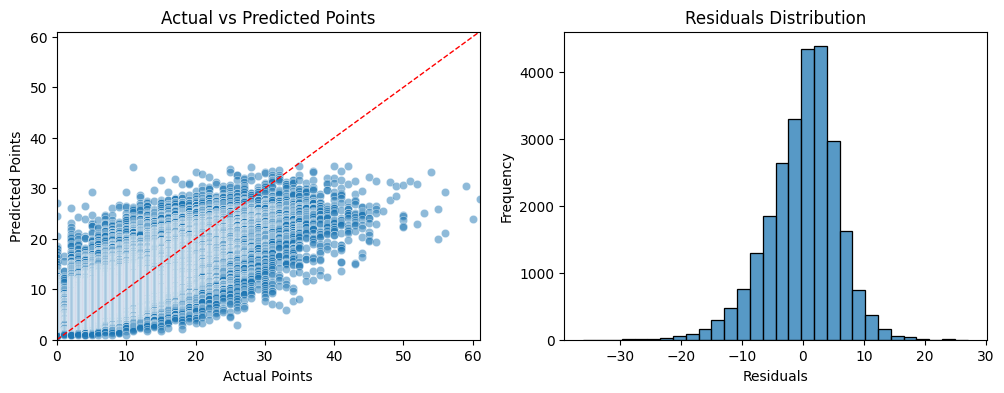

In [20]:
fig, axes = plt.subplots(1,2, figsize=(12, 4))

sns.scatterplot(x='actual', y='predicted', data=residuals_df, palette='light:m_r', alpha=0.5, ax=axes[0])
minVal = min(residuals_df['actual'].min(), residuals_df['predicted'].min())
maxVal = max(residuals_df['actual'].max(), residuals_df['predicted'].max())
axes[0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0].set_xlim(minVal, maxVal)
axes[0].set_ylim(minVal, maxVal)
axes[0].set_title('Actual vs Predicted Points')
axes[0].set_xlabel('Actual Points')
axes[0].set_ylabel('Predicted Points')

sns.histplot(residuals_df['residual'], bins=30, palette='light:m_r', ax=axes[1])
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')

plt.show()

- Currently my model isnt able to predict games were players score above 30+ points

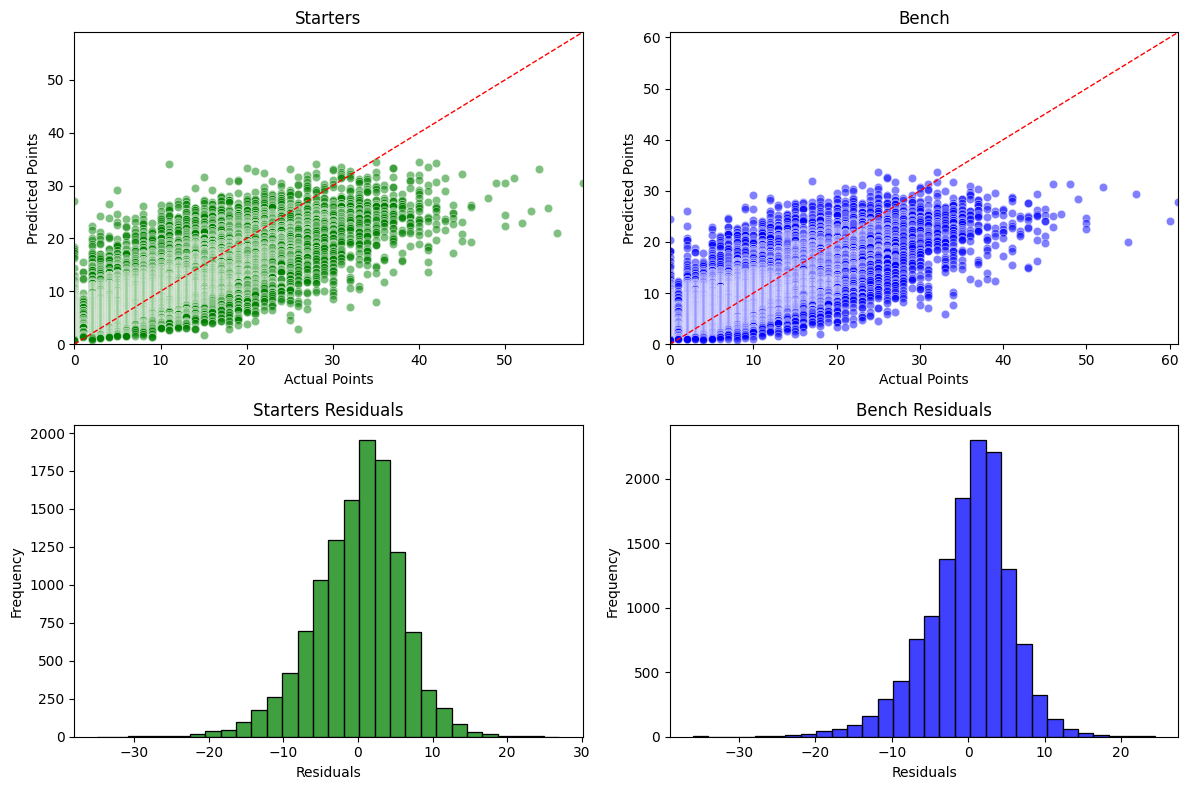

In [21]:
starters = residuals_df[residuals_df['STARTING'] == 1] 
bench = residuals_df[residuals_df['STARTING'] == 0]

fig, axes = plt.subplots(2, 2, figsize=(12, 8)) 

sns.scatterplot(x='actual', y='predicted', data=starters, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(starters['actual'].min(), starters['predicted'].min())
maxVal = max(starters['actual'].max(), starters['predicted'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title('Starters')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

sns.scatterplot(x='actual', y='predicted', data=bench, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(bench['actual'].min(), bench['predicted'].min())
maxVal = max(bench['actual'].max(), bench['predicted'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title('Bench')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

sns.histplot(starters['residual'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('Starters Residuals')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

sns.histplot(bench['residual'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Bench Residuals')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()


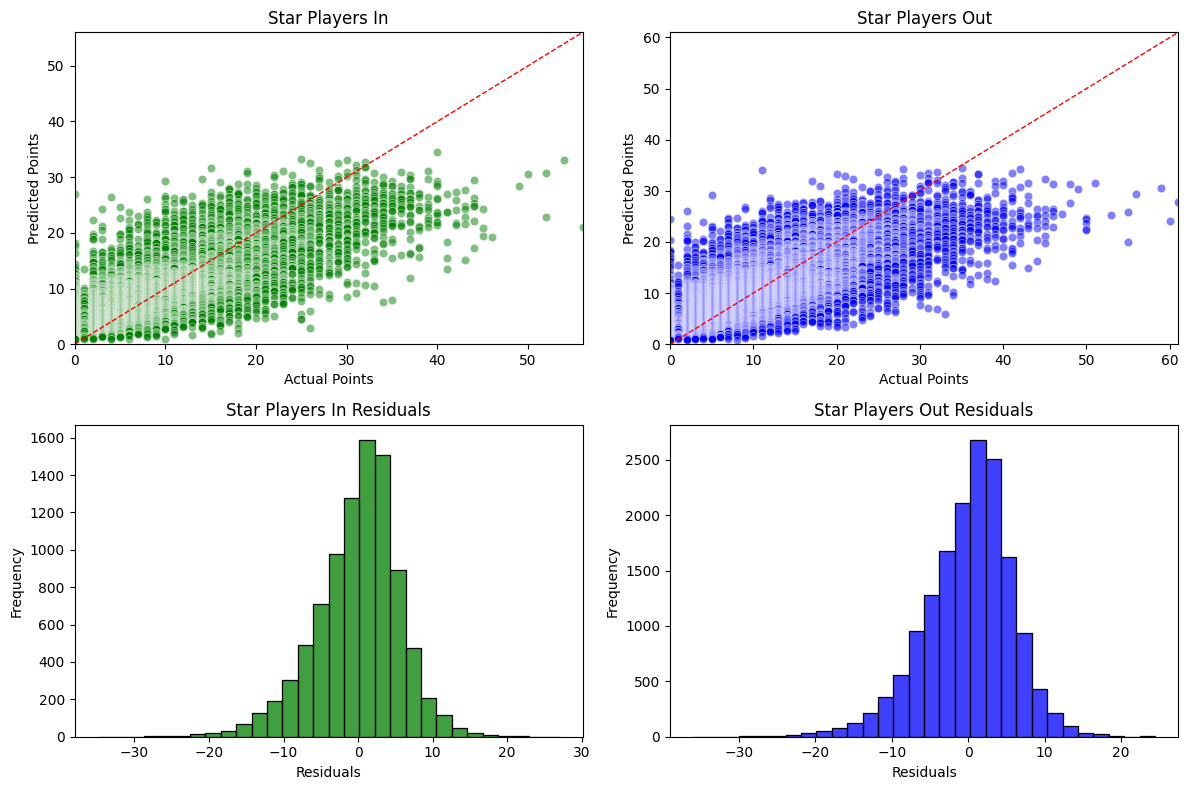

In [22]:
starsIn = residuals_df[residuals_df['TEAM_STAR_OUT'] == 1]
starsOut = residuals_df[residuals_df['TEAM_STAR_OUT'] == 0]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))  

sns.scatterplot(x='actual', y='predicted', data=starsIn, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(starsIn['actual'].min(), starsIn['predicted'].min())
maxVal = max(starsIn['actual'].max(), starsIn['predicted'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title('Star Players In')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

sns.scatterplot(x='actual', y='predicted', data=starsOut, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(starsOut['actual'].min(), starsOut['predicted'].min())
maxVal = max(starsOut['actual'].max(), starsOut['predicted'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title('Star Players Out')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

sns.histplot(starsIn['residual'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('Star Players In Residuals')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

sns.histplot(starsOut['residual'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Star Players Out Residuals')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()



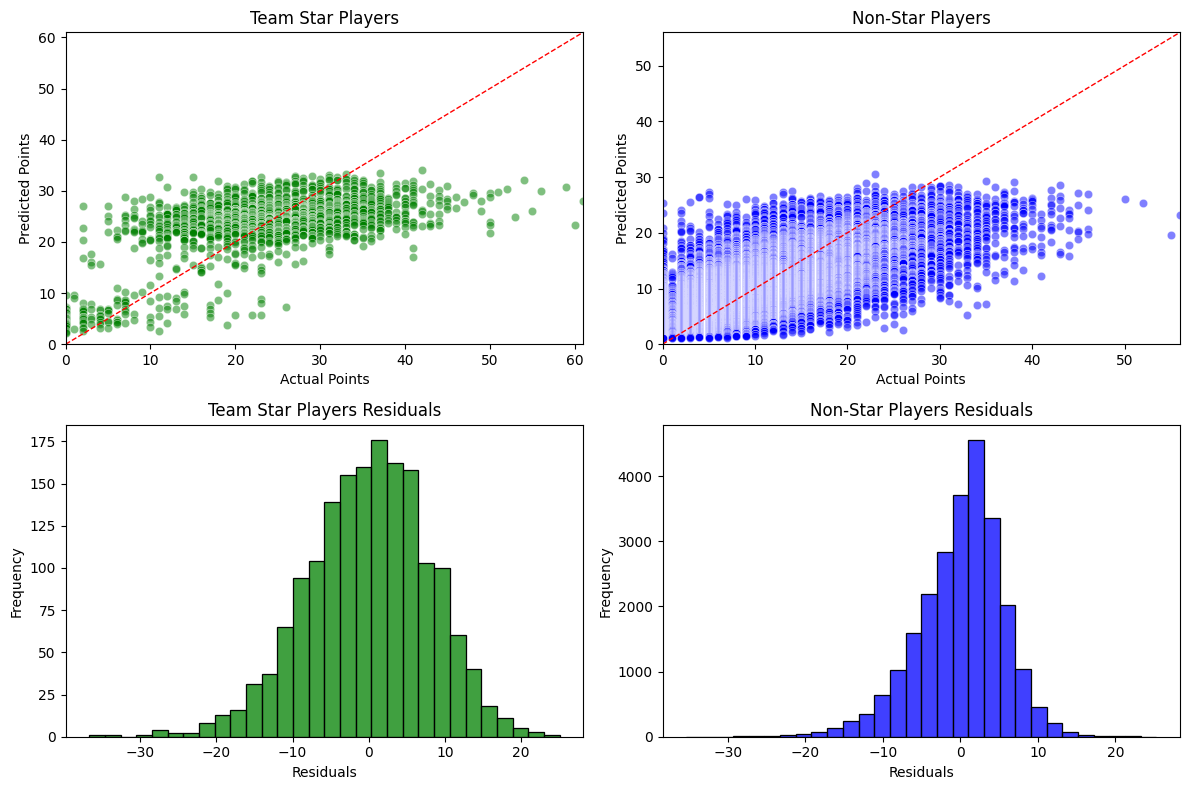

In [ ]:
starPlayers = residuals_df[residuals_df['PLAYER_IS_TEAM_STAR'] == 1]
nonStarPlayers = residuals_df[residuals_df['PLAYER_IS_TEAM_STAR'] == 0]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))  

sns.scatterplot(x='actual', y='predicted', data=starPlayers, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(starPlayers['actual'].min(), starPlayers['predicted'].min())
maxVal = max(starPlayers['actual'].max(), starPlayers['predicted'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title('Team Star Players')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

sns.scatterplot(x='actual', y='predicted', data=nonStarPlayers, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(nonStarPlayers['actual'].min(), nonStarPlayers['predicted'].min())
maxVal = max(nonStarPlayers['actual'].max(), nonStarPlayers['predicted'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title('Non-Star Players')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

sns.histplot(starPlayers['residual'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('Team Star Players Residuals')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

sns.histplot(nonStarPlayers['residual'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Non-Star Players Residuals')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()

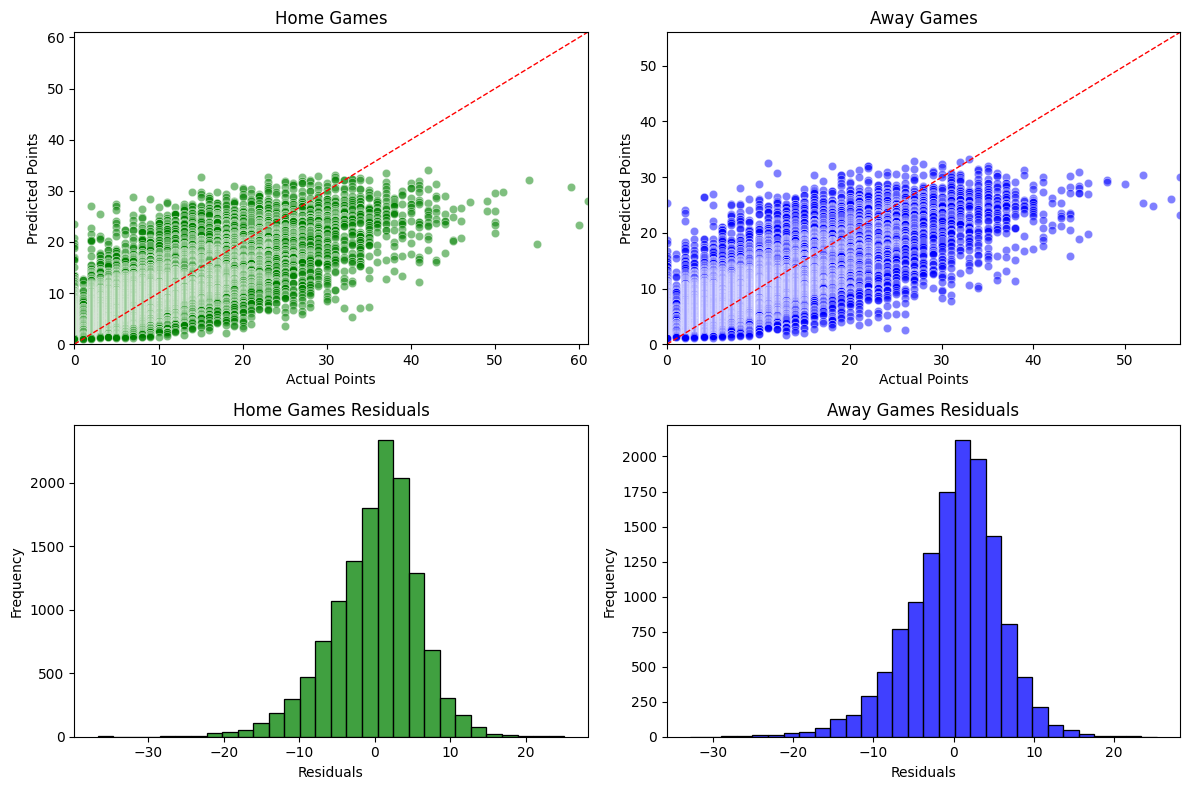

In [ ]:
homeGames = residuals_df[residuals_df['HOME_GAME'] == 1]
awayGames = residuals_df[residuals_df['HOME_GAME'] == 0]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))  

sns.scatterplot(x='actual', y='predicted', data=homeGames, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(homeGames['actual'].min(), homeGames['predicted'].min())
maxVal = max(homeGames['actual'].max(), homeGames['predicted'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title('Home Games')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

sns.scatterplot(x='actual', y='predicted', data=awayGames, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(awayGames['actual'].min(), awayGames['predicted'].min())
maxVal = max(awayGames['actual'].max(), awayGames['predicted'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title('Away Games')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

sns.histplot(homeGames['residual'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('Home Games Residuals')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

sns.histplot(awayGames['residual'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Away Games Residuals')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()

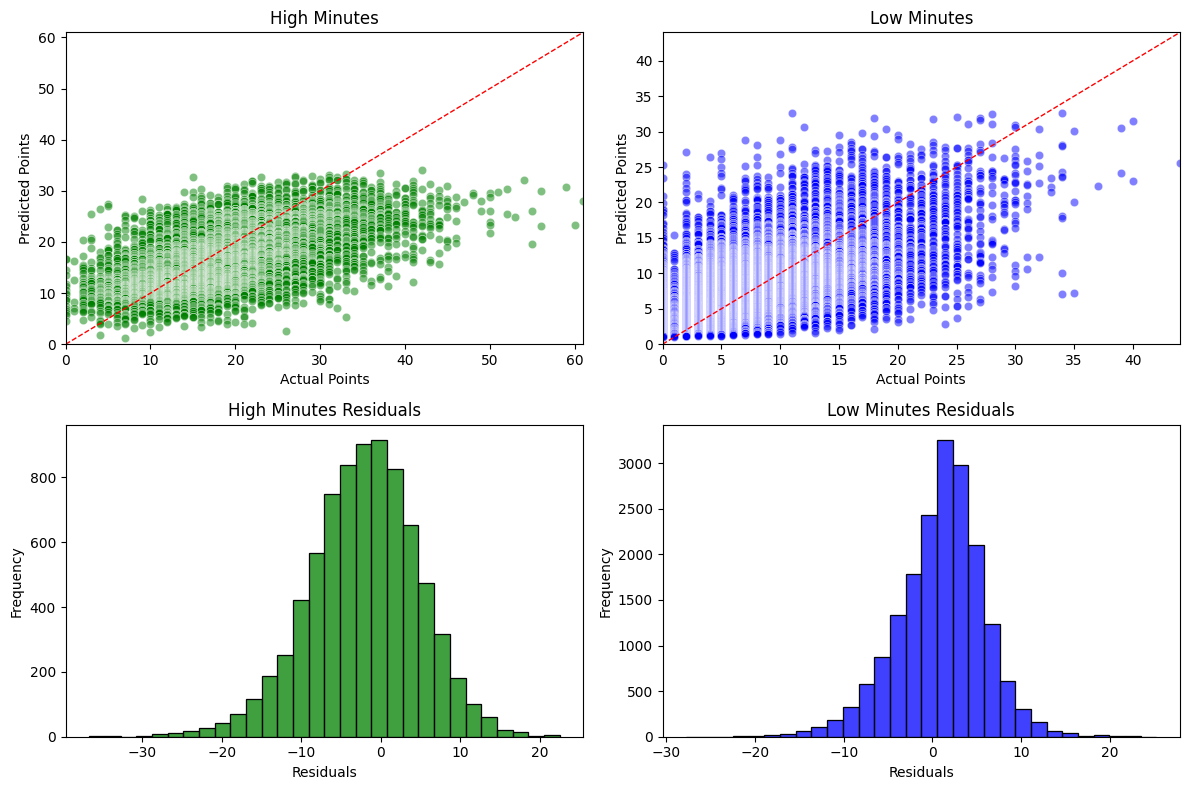

In [ ]:
highMins = residuals_df[residuals_df['MIN'] > 30]
lowMins = residuals_df[residuals_df['MIN'] <= 30]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))  

sns.scatterplot(x='actual', y='predicted', data=highMins, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(highMins['actual'].min(), highMins['predicted'].min())
maxVal = max(highMins['actual'].max(), highMins['predicted'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title('High Minutes')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

sns.scatterplot(x='actual', y='predicted', data=lowMins, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(lowMins['actual'].min(), lowMins['predicted'].min())
maxVal = max(lowMins['actual'].max(), lowMins['predicted'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title('Low Minutes')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

sns.histplot(highMins['residual'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('High Minutes Residuals')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

sns.histplot(lowMins['residual'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Low Minutes Residuals')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()